In [15]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
print("ready")

ready


In [16]:
# Synthetic housing data: 0.8*area + 5 + noise
n = 100
X = np.linspace(0, 10, n)
true_w, true_b = 0.8, 5
noise = np.random.uniform(0, 12, size=n) 
y = true_w * X + true_b + noise

# Train/test split by hand 
idx = np.random.permutation(n) # permute means randomly shuffle the indices of the data points
train_idx, test_idx = idx[:80], idx[80:] # first 80 indices for training, last 20 for testing
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

# Feature scaling: fit on train only apply to both
mu, sigma = X_train.mean(), X_train.std()
X_train_s = (X_train - mu)/sigma 
X_test_s = (X_test - mu)/sigma


### The model: Hypothesis, cost, gradients, training loop 0

In [27]:
def fit(X, y, alpha=0.1, epoch=400):
    """ the training loop of linear regression """
    w, b = 0, 0
    history = [] 
    for epoch in range(epoch):
        J = compute_cost(X, y, w, b)
        history.append(J)
        dJ_dw, dJ_db = compute_gradient(X, y, w, b)
        w = w - alpha * dJ_dw
        b = b - alpha * dJ_db
        if epoch % 50 == 0:
            print(f"epoch {epoch:4d} J={J:10.4f} w={w:7.4f} b={b:10.4f}")
    return w, b, history

w, b, history = fit(X_train_s, y_train, alpha=0.1, epoch=400)
print("Learned (on scaled x): w =", round(w, 4), "b =", round(b, 4))

epoch    0 J=  118.1804 w= 0.2524 b=    1.4727
epoch   50 J=    6.5577 w= 2.5123 b=   14.6586
epoch  100 J=    6.5548 w= 2.5240 b=   14.7265
epoch  150 J=    6.5548 w= 2.5240 b=   14.7269
epoch  200 J=    6.5548 w= 2.5240 b=   14.7269
epoch  250 J=    6.5548 w= 2.5240 b=   14.7269
epoch  300 J=    6.5548 w= 2.5240 b=   14.7269
epoch  350 J=    6.5548 w= 2.5240 b=   14.7269
Learned (on scaled x): w = 2.524 b = 14.7269


### Diagnostics - Loss Curve and Fitted line

Text(0.5, 1.0, 'Fitted line on training data')

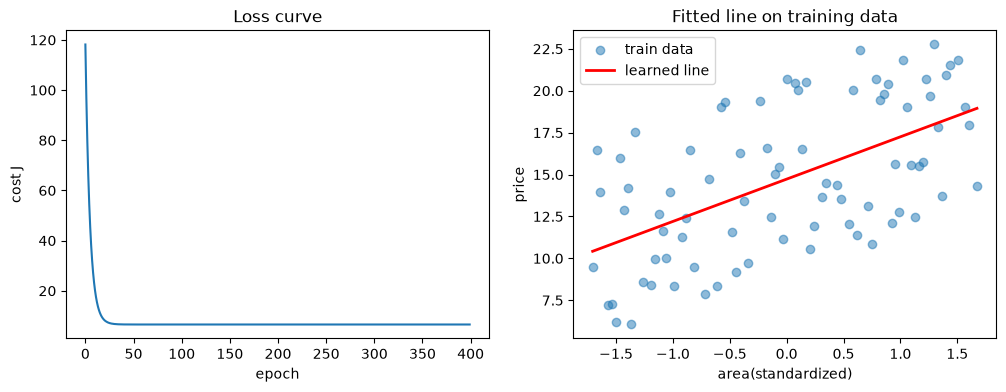

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# Loss curve (the alpha diagnostic)
# Healthy = steep fall, then smoothen plateau
ax1.plot(history)
ax1.set_xlabel("epoch"); ax1.set_ylabel("cost J"); ax1.set_title("Loss curve")

# Fitted line over the training data
ax2.scatter(X_train_s, y_train, alpha=0.5, label="train data")
xs = np.linspace(X_train_s.min(), X_train_s.max(), 100)
ax2.plot(xs, predict(xs, w, b), color="red", linewidth=2, label="learned line")
ax2.set_xlabel("area(standardized)"); ax2.set_ylabel("price")
ax2.legend(); ax2.set_title("Fitted line on training data")


### Testing loop and evaluation

In [29]:
# Testing loop : parameter frozen - forward pass only
y_pred = predict(X_test_s, w, b)

# Metrics copmuted from their formulas
mae = np.mean(np.abs(y_pred - y_test))
mse = np.mean((y_pred - y_test)**2)
rmse = np.sqrt(mse)
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - (ss_res/ss_tot)

print(f"MAE = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R2 = {r2:.3f}")

MAE = 2.781
RMSE = 3.265
R2 = 0.233


### Verification against scicit-learn

In [30]:
from sklearn.linear_model import LinearRegression

sk = LinearRegression()
sk.fit(X_train_s.reshape(-1, 1), y_train)
print("sklearn : w =", round(sk.coef_[0], 4), "b =", round(sk.intercept_, 4))
print("raw code: w =", round(w, 4), "b =", round(b, 4))

# The values agree (to small numerical tolerance):
# model.fit() perfomrs the same minimization just implemented by hand

sklearn : w = 2.524 b = 14.7269
raw code: w = 2.524 b = 14.7269
